In [1]:
import sys
import os
sys.path.append('..')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from IPython.display import display, Markdown

In [3]:
from scripts.analysis import QueryAnalyzer

In [4]:
analyzer = QueryAnalyzer()

In [9]:
display(Markdown("## Запуск анализа производительности с EXPLAIN ANALYZE"))

def collect_all_data_with_explain():
    tasks_methods = [
        analyzer.task1_queries,
        analyzer.task2_queries,
        analyzer.task3_queries,
        analyzer.task4_queries,
        analyzer.task5_queries,
        analyzer.task6_queries,
        analyzer.task7_queries,
    ]
    
    all_results = []
    
    for i, task_method in enumerate(tasks_methods, 1):
        display(Markdown(f"### Выполнение задания {i}..."))
        
        try:
            result = task_method()
            result['task_number'] = i
            all_results.append(result)
            
            planning_time_with_index = result['plan_with_index'][0]['Planning Time'] if result['plan_with_index'] else 0
            execution_time_with_index = result['plan_with_index'][0]['Execution Time'] if result['plan_with_index'] else 0
            planning_time_without_index = result['plan_without_index'][0]['Planning Time'] if result['plan_without_index'] else 0
            execution_time_without_index = result['plan_without_index'][0]['Execution Time'] if result['plan_without_index'] else 0
            
            display(Markdown(f"""
            **Результаты задания {i} - {result['task']}:**
            
            **С индексом:**
            - Общее время: {result['time_with_index']:.2f} ms
            - Время планирования: {planning_time_with_index:.2f} ms
            - Время выполнения: {execution_time_with_index:.2f} ms
            - Найдено записей: {result['count_with_index']}
            
            **Без индекса:**
            - Общее время: {result['time_without_index']:.2f} ms
            - Время планирования: {planning_time_without_index:.2f} ms
            - Время выполнения: {execution_time_without_index:.2f} ms
            - Найдено записей: {result['count_without_index']}
            
            **Ускорение:** {result['time_without_index']/result['time_with_index']:.1f}x
            """))
            
        except Exception as e:
            print(f"Ошибка при выполнении задания {i}: {e}")
            continue
    
    return pd.DataFrame(all_results)

df_real = collect_all_data_with_explain()

## Запуск анализа производительности с EXPLAIN ANALYZE

### Выполнение задания 1...


            **Результаты задания 1 - Поиск отзывов по user_id:**

            **С индексом:**
            - Общее время: 1.51 ms
            - Время планирования: 0.03 ms
            - Время выполнения: 0.02 ms
            - Найдено записей: 4

            **Без индекса:**
            - Общее время: 177.44 ms
            - Время планирования: 0.05 ms
            - Время выполнения: 170.36 ms
            - Найдено записей: 4

            **Ускорение:** 117.3x
            

### Выполнение задания 2...


            **Результаты задания 2 - Составной индекс для user_id и timestamp:**

            **С индексом:**
            - Общее время: 1.15 ms
            - Время планирования: 0.03 ms
            - Время выполнения: 0.01 ms
            - Найдено записей: 4

            **Без индекса:**
            - Общее время: 201.00 ms
            - Время планирования: 0.05 ms
            - Время выполнения: 155.33 ms
            - Найдено записей: 4

            **Ускорение:** 175.3x
            

...


            **Результаты задания 5 - Регистронезависимый поиск:**

            **С индексом:**
            - Общее время: 1242.95 ms
            - Время планирования: 0.10 ms
            - Время выполнения: 1215.04 ms
            - Найдено записей: 2

            **Без индекса:**
            - Общее время: 1240.08 ms
            - Время планирования: 0.08 ms
            - Время выполнения: 1217.29 ms
            - Найдено записей: 2

            **Ускорение:** 1.0x
            

### Выполнение задания 6...

Ошибка при выполнении задания 6: float division by zero


### Выполнение задания 7...


            **Результаты задания 7 - Пользователи с большим количеством низких оценок:**

            **С индексом:**
            - Общее время: 4422.28 ms
            - Время планирования: 0.08 ms
            - Время выполнения: 5012.87 ms
            - Найдено записей: 0

            **Без индекса:**
            - Общее время: 6816.16 ms
            - Время планирования: 0.07 ms
            - Время выполнения: 7470.14 ms
            - Найдено записей: 0

            **Ускорение:** 1.5x
            

/usr/local/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/usr/local/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


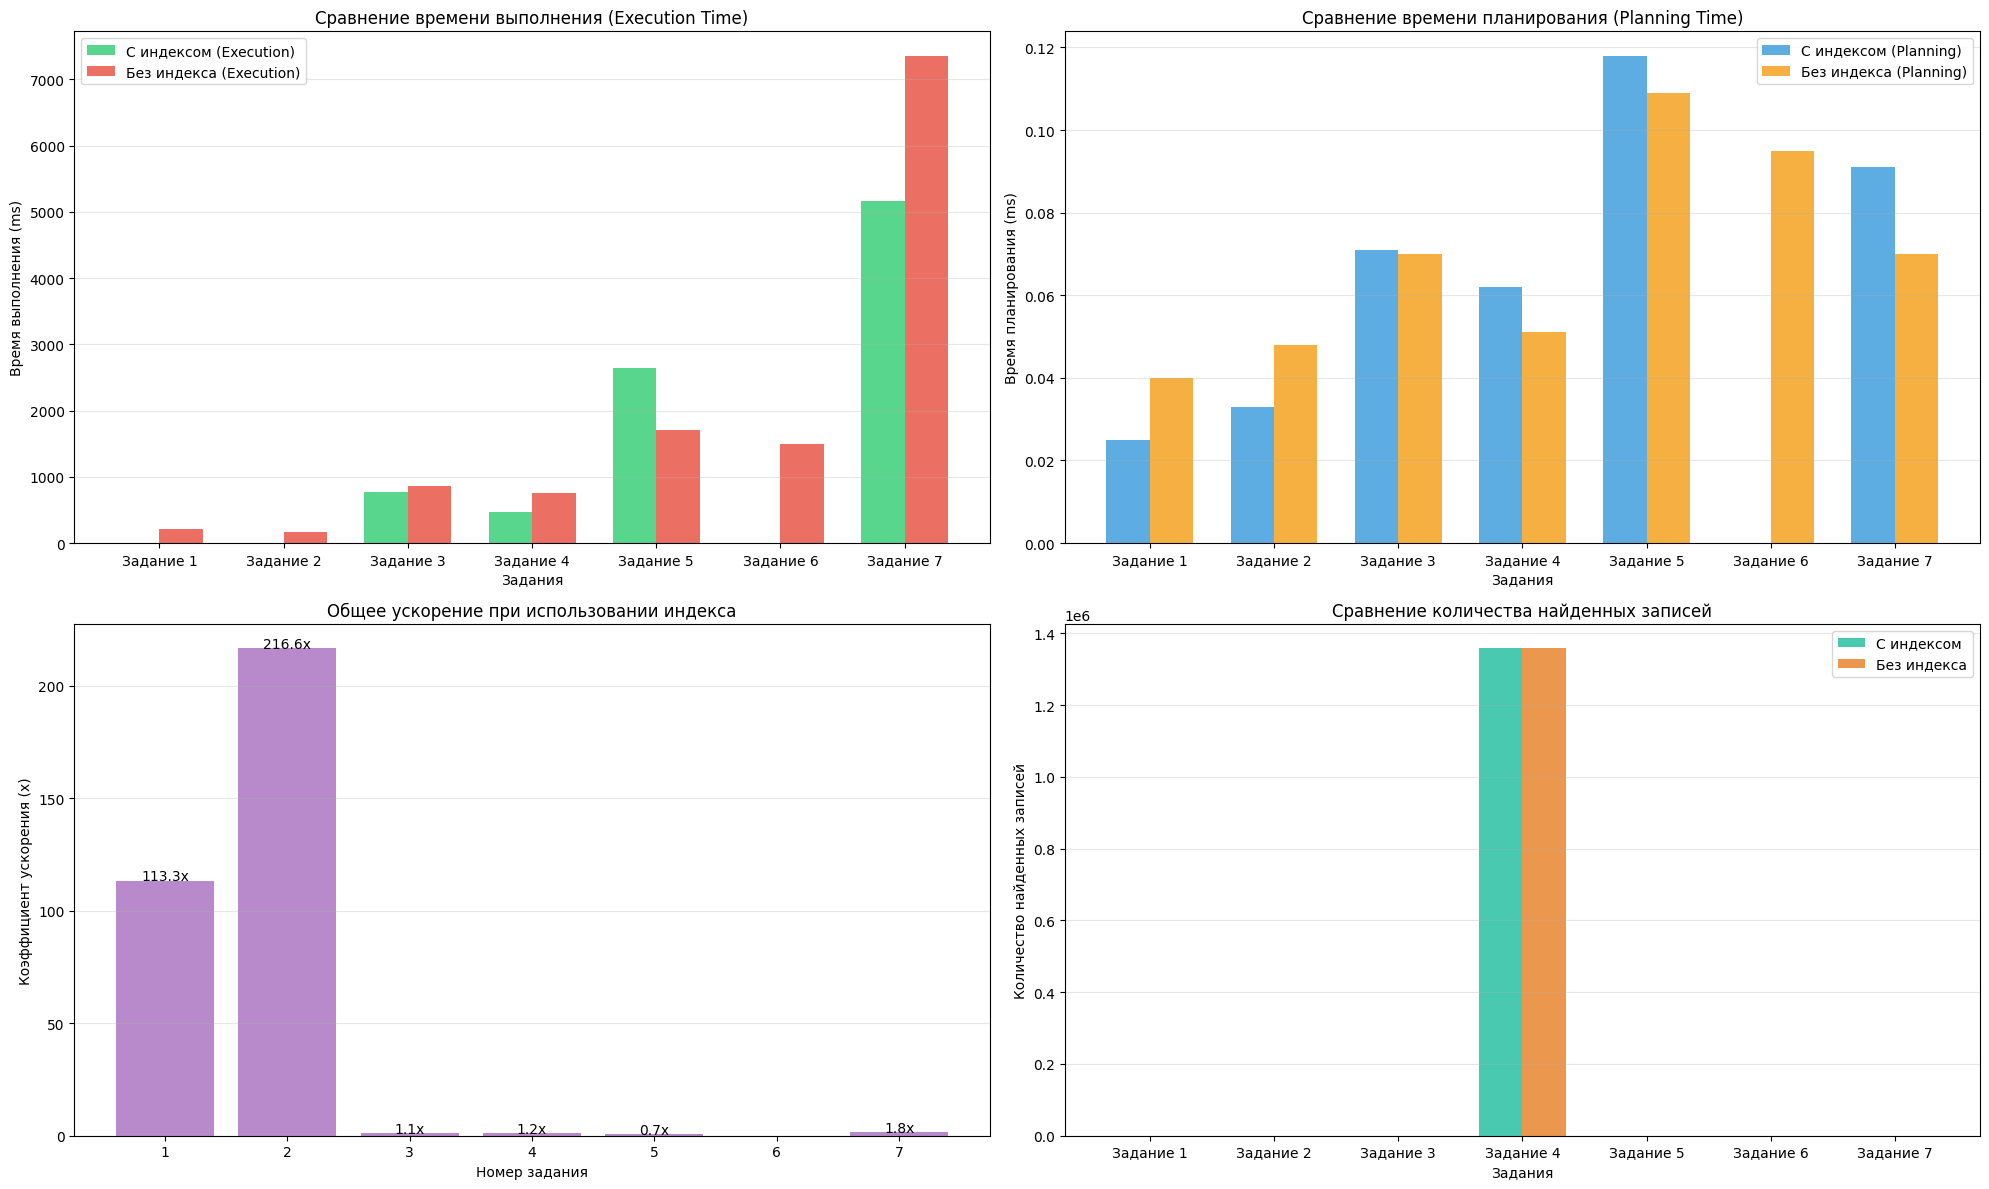

In [8]:
def create_detailed_performance_chart(df):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))
    
    execution_times_with_index = []
    execution_times_without_index = []
    planning_times_with_index = []
    planning_times_without_index = []
    
    for _, row in df.iterrows():
        if row['plan_with_index']:
            execution_times_with_index.append(row['plan_with_index'][0]['Execution Time'])
            planning_times_with_index.append(row['plan_with_index'][0]['Planning Time'])
        else:
            execution_times_with_index.append(0)
            planning_times_with_index.append(0)
            
        if row['plan_without_index']:
            execution_times_without_index.append(row['plan_without_index'][0]['Execution Time'])
            planning_times_without_index.append(row['plan_without_index'][0]['Planning Time'])
        else:
            execution_times_without_index.append(0)
            planning_times_without_index.append(0)
    
    x = range(len(df))
    width = 0.35
    ax1.bar([i - width/2 for i in x], execution_times_with_index, width, 
            label='С индексом (Execution)', alpha=0.8, color='#2ecc71')
    ax1.bar([i + width/2 for i in x], execution_times_without_index, width, 
            label='Без индекса (Execution)', alpha=0.8, color='#e74c3c')
    ax1.set_xlabel('Задания')
    ax1.set_ylabel('Время выполнения (ms)')
    ax1.set_title('Сравнение времени выполнения (Execution Time)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'Задание {i}' for i in df['task_number']])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    ax2.bar([i - width/2 for i in x], planning_times_with_index, width, 
            label='С индексом (Planning)', alpha=0.8, color='#3498db')
    ax2.bar([i + width/2 for i in x], planning_times_without_index, width, 
            label='Без индекса (Planning)', alpha=0.8, color='#f39c12')
    ax2.set_xlabel('Задания')
    ax2.set_ylabel('Время планирования (ms)')
    ax2.set_title('Сравнение времени планирования (Planning Time)')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'Задание {i}' for i in df['task_number']])
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    df['Ускорение'] = df['time_without_index'] / df['time_with_index']
    ax3.bar(df['task_number'], df['Ускорение'], color='#9b59b6', alpha=0.7)
    ax3.set_xlabel('Номер задания')
    ax3.set_ylabel('Коэффициент ускорения (x)')
    ax3.set_title('Общее ускорение при использовании индекса')
    ax3.grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(df['Ускорение']):
        ax3.text(df['task_number'].iloc[i], v + 0.1, f'{v:.1f}x', ha='center')
    
    ax4.bar([i - width/2 for i in x], df['count_with_index'], width, 
            label='С индексом', alpha=0.8, color='#1abc9c')
    ax4.bar([i + width/2 for i in x], df['count_without_index'], width, 
            label='Без индекса', alpha=0.8, color='#e67e22')
    ax4.set_xlabel('Задания')
    ax4.set_ylabel('Количество найденных записей')
    ax4.set_title('Сравнение количества найденных записей')
    ax4.set_xticks(x)
    ax4.set_xticklabels([f'Задание {i}' for i in df['task_number']])
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

create_detailed_performance_chart(df_real)

In [45]:
def analyze_query_plans(df):
    for _, row in df.iterrows():
        display(Markdown(f"### Задание {row['task_number']}: {row['task']}"))
        
        if row['plan_with_index']:
            plan_with_index = row['plan_with_index'][0]
            display(Markdown(f"""
            **С индексом:**
            - Узел плана: {plan_with_index['Plan']['Node Type']}
            - Стоимость: {plan_with_index['Plan']['Total Cost']:.2f}
            - Фактические строки: {plan_with_index['Plan']['Actual Rows']}
            - Время планирования: {plan_with_index['Planning Time']:.2f} ms
            - Время выполнения: {plan_with_index['Execution Time']:.2f} ms
            """))
        
        if row['plan_without_index']:
            plan_without_index = row['plan_without_index'][0]
            display(Markdown(f"""
            **Без индекса:**
            - Узел плана: {plan_without_index['Plan']['Node Type']}
            - Стоимость: {plan_without_index['Plan']['Total Cost']:.2f}
            - Фактические строки: {plan_without_index['Plan']['Actual Rows']}
            - Время планирования: {plan_without_index['Planning Time']:.2f} ms
            - Время выполнения: {plan_without_index['Execution Time']:.2f} ms
            """))

analyze_query_plans(df_real)

### Задание 1: Поиск отзывов по user_id


            **С индексом:**
            - Узел плана: Index Scan
            - Стоимость: 28.54
            - Фактические строки: 4
            - Время планирования: 0.03 ms
            - Время выполнения: 0.01 ms
            


            **Без индекса:**
            - Узел плана: Gather
            - Стоимость: 106962.25
            - Фактические строки: 4
            - Время планирования: 0.04 ms
            - Время выполнения: 162.79 ms
            

### Задание 2: Поиск отзывов по product_id


            **С индексом:**
            - Узел плана: Index Scan
            - Стоимость: 28.66
            - Фактические строки: 4
            - Время планирования: 0.02 ms
            - Время выполнения: 0.01 ms
            

...


            **С индексом:**
            - Узел плана: Aggregate
            - Стоимость: 222075.21
            - Фактические строки: 5
            - Время планирования: 0.07 ms
            - Время выполнения: 708.38 ms
            


            **Без индекса:**
            - Узел плана: Aggregate
            - Стоимость: 222075.51
            - Фактические строки: 5
            - Время планирования: 0.07 ms
            - Время выполнения: 848.46 ms
            

### Задание 7: Сложный запрос с несколькими условиями


            **С индексом:**
            - Узел плана: Seq Scan
            - Стоимость: 202137.44
            - Фактические строки: 4132704
            - Время планирования: 0.08 ms
            - Время выполнения: 909.34 ms
            


            **Без индекса:**
            - Узел плана: Seq Scan
            - Стоимость: 202137.89
            - Фактические строки: 4132704
            - Время планирования: 0.05 ms
            - Время выполнения: 880.08 ms
            